In [1]:
import pandas as pd
file=pd.read_csv(r"../data/raw/employee_data.csv")
file.head()

,EmpID,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,...,Division,DOB,State,JobFunctionDescription,GenderCode,LocationCode,RaceDesc,MaritalDesc,Performance Score,Current Employee Rating
0,3427,Uriah,Bridges,20-Sep-19,NaN,Production Technician I,Peter Oneill,uriah.bridges@bilearner.com,CCDR,Active,...,Finance & Accounting,7/10/1969,MA,Accounting,Female,34904,White,Widowed,Fully Meets,4
1,3428,Paula,Small,11-Feb-23,NaN,Production Technician I,Renee Mccormick,paula.small@bilearner.com,EW,Active,...,Aerial,30-08-1965,MA,Labor,Male,6593,Hispanic,Widowed,Fully Meets,3
2,3429,Edward,Buck,10-Dec-18,NaN,Area Sales Manager,Crystal Walker,edward.buck@bilearner.com,PL,Active,...,General - Sga,6/10/1991,MA,Assistant,Male,2330,Hispanic,Widowed,Fully Meets,4
3,3430,Michael,Riordan,21-Jun-21,NaN,Area Sales Manager,Rebekah Wright,michael.riordan@bilearner.com,CCDR,Active,...,Finance & Accounting,4/4/1998,ND,Clerk,Male,58782,Other,Single,Fully Meets,2
4,3431,Jasmine,Onque,29-Jun-19,NaN,Area Sales Manager,Jason Kim,jasmine.onque@bilearner.com,TNS,Active,...,General - Con,29-08-1969,FL,Laborer,Female,33174,Other,Married,Fully Meets,3


In [2]:
print("column names: ")
for col in file.columns:
    print(col)

column names: 
EmpID
FirstName
LastName
StartDate
ExitDate
Title
Supervisor
ADEmail
BusinessUnit
EmployeeStatus
EmployeeType
PayZone
EmployeeClassificationType
TerminationType
TerminationDescription
DepartmentType
Division
DOB
State
JobFunctionDescription
GenderCode
LocationCode
RaceDesc
MaritalDesc
Performance Score
Current Employee Rating


In [2]:
import pandas as pd
import os

# Step 1: Define paths
input_path = r"../data/raw/employee_data.csv"
output_folder = "../data/processed/"
os.makedirs(output_folder, exist_ok=True)

# Step 2: Load the dataset
df = pd.read_csv(input_path)

# Step 3: Drop irrelevant columns
columns_to_drop = ['FirstName', 'LastName', 'ADEmail']
df = df.drop(columns=columns_to_drop, errors='ignore')

# Step 4: Select the same 5 random samples for before & after comparison
sample_indices = df.sample(5, random_state=42).index  # fixed seed for reproducibility

print("🔹 BEFORE Date Conversion:")
print(df.loc[sample_indices, ['StartDate', 'ExitDate']])

# Step 5: Convert StartDate and ExitDate to datetime
df['StartDate'] = pd.to_datetime(df['StartDate'], errors='coerce')
df['ExitDate'] = pd.to_datetime(df['ExitDate'], errors='coerce')

# Step 6: Show the same samples after conversion
print("\n🔸 AFTER Date Conversion:")
print(df.loc[sample_indices, ['StartDate', 'ExitDate']])

# Step 7: Save cleaned data
output_path = os.path.join(output_folder, "cleaned_converted_employee_data.csv")
df.to_csv(output_path, index=False)

print(f"\n✅ Cleaned and converted data saved to: {output_path}")


🔹 BEFORE Date Conversion:
      StartDate   ExitDate
1801  12-Aug-18  13-Jun-22
1190  18-Feb-22        NaN
1817   4-Aug-22        NaN
251   22-Jul-21        NaN
2505  19-Aug-21  25-May-23

🔸 AFTER Date Conversion:
      StartDate   ExitDate
1801 2018-08-12 2022-06-13
1190 2022-02-18        NaT
1817 2022-08-04        NaT
251  2021-07-22        NaT
2505 2021-08-19 2023-05-25

✅ Cleaned and converted data saved to: D:\DATASCIENCE AND AI\ANALYTICS\internship\mark 5\cleaned dataset\cleaned_converted_employee_data.csv


C:\Users\alanm\AppData\Local\Temp\ipykernel_15420\2664922456.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['StartDate'] = pd.to_datetime(df['StartDate'], errors='coerce')
C:\Users\alanm\AppData\Local\Temp\ipykernel_15420\2664922456.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ExitDate'] = pd.to_datetime(df['ExitDate'], errors='coerce')


C:\Users\alanm\AppData\Local\Temp\ipykernel_23192\121825613.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis', ax=axes[idx, 0])
C:\Users\alanm\AppData\Local\Temp\ipykernel_23192\121825613.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis', ax=axes[idx, 0])
C:\Users\alanm\AppData\Local\Temp\ipykernel_23192\121825613.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, p

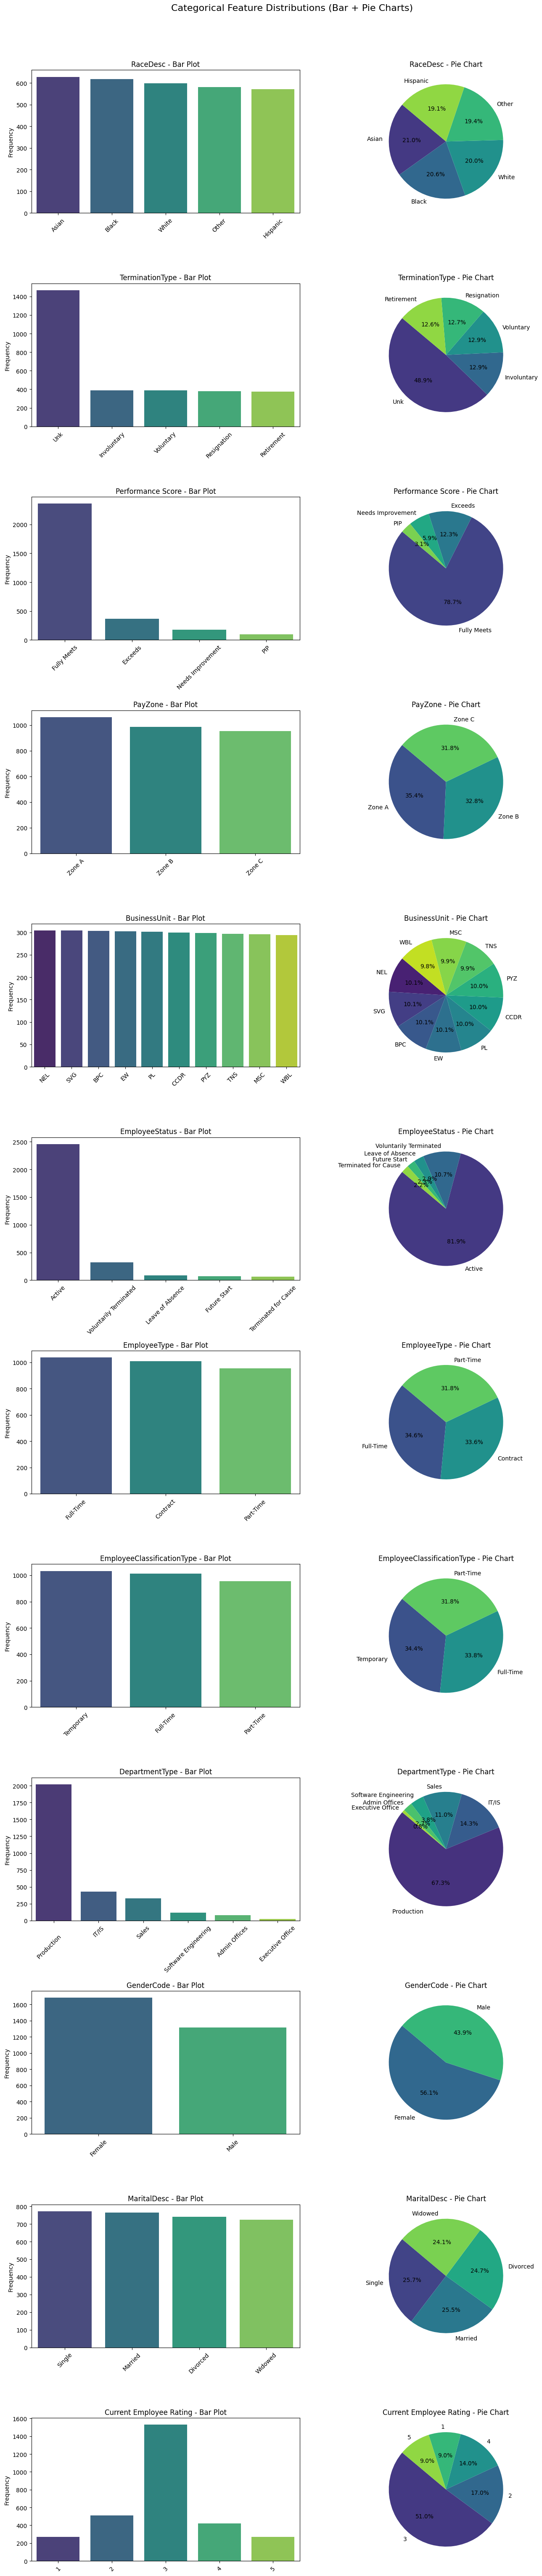

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Step 1: Load the dataset
file_path = r"../data/raw/employee_data.csv"
df = pd.read_csv(file_path)

# Step 2: List of columns to analyze (ensure no empty strings or duplicates)
columns_to_analyze = [
    'RaceDesc', 'TerminationType', 'Performance Score', 'PayZone',
    'BusinessUnit', 'EmployeeStatus', 'EmployeeType',
    'EmployeeClassificationType', 'DepartmentType', 'GenderCode',
    'MaritalDesc', 'Current Employee Rating'
]

# Step 3: Setup subplot layout (2 plots per column: bar + pie)
num_cols = len(columns_to_analyze)
fig, axes = plt.subplots(num_cols, 2, figsize=(14, 5 * num_cols))  # rows = num_cols, 2 columns per row

# Step 4: Loop through each column and plot bar + pie
for idx, column_name in enumerate(columns_to_analyze):
    value_counts = df[column_name].value_counts()

    # Bar Plot
    sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis', ax=axes[idx, 0])
    axes[idx, 0].set_title(f"{column_name} - Bar Plot", fontsize=12)
    axes[idx, 0].set_xlabel("")
    axes[idx, 0].set_ylabel("Frequency")
    axes[idx, 0].tick_params(axis='x', rotation=45)

    # Pie Chart
    axes[idx, 1].pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(value_counts)))
    axes[idx, 1].set_title(f"{column_name} - Pie Chart", fontsize=12)

# Step 5: Adjust layout
plt.tight_layout()
plt.suptitle("Categorical Feature Distributions (Bar + Pie Charts)", fontsize=16, y=1.02)
plt.show()


In [7]:
import pandas as pd

# Load dataset
file_path = r"../data/raw/employee_data.csv"
df = pd.read_csv(file_path)

# List of columns to analyze
columns_to_check = ['Title']#d or modify as needed

# Print unique values as Python lists
for column in columns_to_check:
    unique_values = df[column].dropna().unique().tolist()
    print(f"\n🔹 Unique values in column '{column}':")
    print(unique_values)



🔹 Unique values in column 'Title':
['Production Technician I', 'Area Sales Manager', 'Production Technician II', 'IT Support', 'Network Engineer', 'Sr. Network Engineer', 'Principal Data Architect', 'Enterprise Architect', 'Sr. DBA', 'Database Administrator', 'Data Analyst', 'Data Analyst ', 'Data Architect', 'CIO', 'BI Director', 'Sr. Accountant', 'Software Engineering Manager', 'Software Engineer', 'Shared Services Manager', 'Senior BI Developer', 'Production Manager', 'President & CEO', 'Administrative Assistant', 'Accountant I', 'BI Developer', 'Sales Manager', 'IT Manager - Support', 'IT Manager - Infra', 'IT Manager - DB', 'Director of Sales', 'Director of Operations', 'IT Director']


🔹 Original Unique Titles:
['Production Technician I', 'Area Sales Manager', 'Production Technician II', 'IT Support', 'Network Engineer', 'Sr. Network Engineer', 'Principal Data Architect', 'Enterprise Architect', 'Sr. DBA', 'Database Administrator', 'Data Analyst', 'Data Architect', 'CIO', 'BI Director', 'Sr. Accountant', 'Software Engineering Manager', 'Software Engineer', 'Shared Services Manager', 'Senior BI Developer', 'Production Manager', 'President & CEO', 'Administrative Assistant', 'Accountant I', 'BI Developer', 'Sales Manager', 'IT Manager - Support', 'IT Manager - Infra', 'IT Manager - DB', 'Director of Sales', 'Director of Operations', 'IT Director']

📌 Sample Mapping Output:
                         Title               JobFamily SeniorityLevel
891   Administrative Assistant         Admin & Support          Entry
589        Senior BI Developer        Data & Analytics         Senior
1194              BI Developer        Data & Analytics          Entry
534                BI

C:\Users\alanm\AppData\Local\Temp\ipykernel_23192\1977487995.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=color_palette)


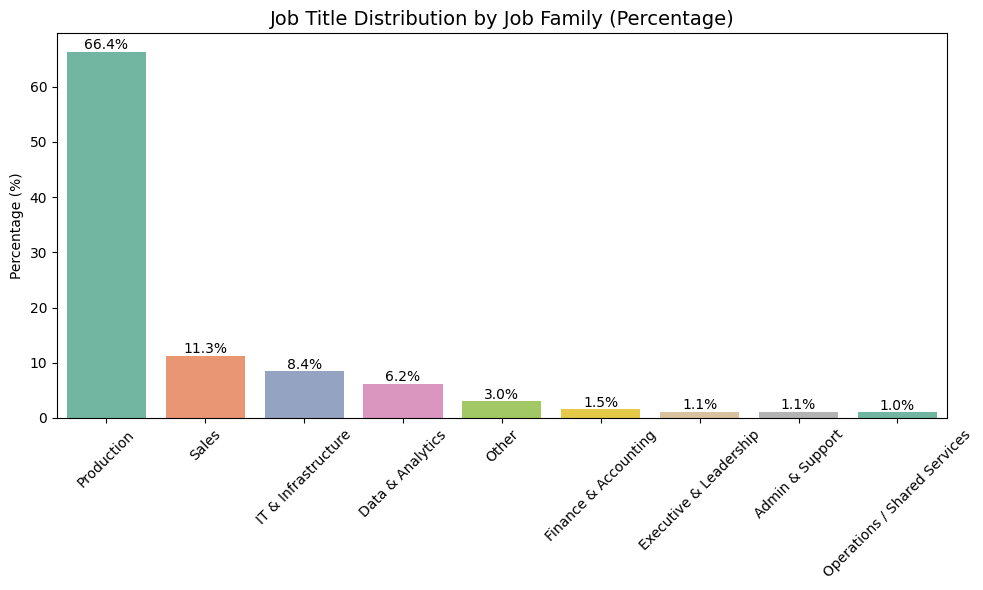

C:\Users\alanm\AppData\Local\Temp\ipykernel_23192\1977487995.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=color_palette)


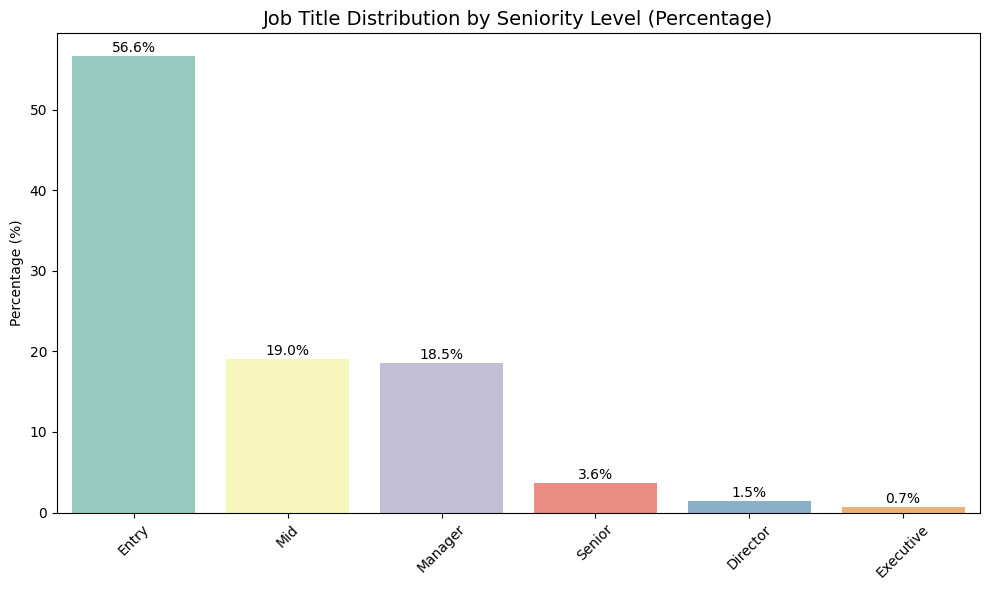


📘 Explanation:

We cleaned and grouped the raw job titles into two simplified categories:
1. JobFamily – Based on department (e.g., IT, Sales, Data).
2. SeniorityLevel – Based on rank (e.g., Entry, Manager, Executive).

These vertical bar charts show the percentage of employees in each category.
This format is useful for comparison and reporting.



In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = r"../data/raw/employee_data.csv"
df = pd.read_csv(file_path)

# Clean Title column: remove extra spaces
df['Title'] = df['Title'].str.strip()

# Display original unique titles
original_titles = df['Title'].dropna().unique().tolist()
print("🔹 Original Unique Titles:")
print(original_titles)

# --- Mapping functions ---

def map_job_family(title):
    title = title.lower()
    if 'data' in title or 'bi' in title or 'dba' in title or 'analyst' in title:
        return 'Data & Analytics'
    elif 'it' in title or 'network' in title or 'infra' in title or 'support' in title:
        return 'IT & Infrastructure'
    elif 'sales' in title:
        return 'Sales'
    elif 'accountant' in title:
        return 'Finance & Accounting'
    elif 'president' in title or 'ceo' in title or 'cio' in title or 'director' in title:
        return 'Executive & Leadership'
    elif 'manager' in title and 'production' not in title:
        return 'Operations / Shared Services'
    elif 'production' in title:
        return 'Production'
    elif 'admin' in title:
        return 'Admin & Support'
    else:
        return 'Other'

def map_seniority_level(title):
    title = title.lower()
    if 'president' in title or 'ceo' in title or 'cio' in title:
        return 'Executive'
    elif 'director' in title:
        return 'Director'
    elif 'manager' in title:
        return 'Manager'
    elif 'sr' in title or 'senior' in title or 'principal' in title:
        return 'Senior'
    elif 'i' in title and 'ii' not in title:
        return 'Entry'
    elif 'ii' in title:
        return 'Mid'
    else:
        return 'Mid'

# Apply mapping
df['JobFamily'] = df['Title'].apply(map_job_family)
df['SeniorityLevel'] = df['Title'].apply(map_seniority_level)

# Sample output
print("\n📌 Sample Mapping Output:")
print(df[['Title', 'JobFamily', 'SeniorityLevel']].drop_duplicates().sort_values(by='JobFamily').head(10))

# --- Plotting helper function: vertical bar with percentage ---
def plot_vertical_bar_percent(series, title, color_palette):
    counts = series.value_counts(normalize=True).mul(100).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=counts.index, y=counts.values, palette=color_palette)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10)
    plt.title(title + " (Percentage)", fontsize=14)
    plt.ylabel("Percentage (%)")
    plt.xlabel("")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# --- Visualization 1: JobFamily ---
plot_vertical_bar_percent(df['JobFamily'], "Job Title Distribution by Job Family", 'Set2')

# --- Visualization 2: SeniorityLevel ---
plot_vertical_bar_percent(df['SeniorityLevel'], "Job Title Distribution by Seniority Level", 'Set3')

# --- Explanation ---
print("\n📘 Explanation:")
print("""
We cleaned and grouped the raw job titles into two simplified categories:
1. JobFamily – Based on department (e.g., IT, Sales, Data).
2. SeniorityLevel – Based on rank (e.g., Entry, Manager, Executive).

These vertical bar charts show the percentage of employees in each category.
This format is useful for comparison and reporting.
""")


In [9]:
import pandas as pd

# Load dataset
file_path = r"../data/raw/employee_data.csv"
df = pd.read_csv(file_path)

# List of columns to analyze
columns_to_check = ['Division']#ify as needed

# Print unique values as Python lists
for column in columns_to_check:
    unique_values = df[column].dropna().unique().tolist()
    print(f"\n🔹 Unique values in column '{column}':")
    print(unique_values)



🔹 Unique values in column 'Division':
['Finance & Accounting', 'Aerial', 'General - Sga', 'General - Con', 'Field Operations', 'General - Eng', 'Engineers', 'Executive', 'Splicing', 'Project Management - Con', 'Fielders', 'Project Management - Eng', 'Shop (Fleet)', 'Wireline Construction', 'Catv', 'Yard (Material Handling)', 'Wireless', 'People Services', 'Underground', 'Billable Consultants', 'Technology / It', 'Sales & Marketing', 'Safety', 'Isp', 'Corp Operations']


C:\Users\alanm\AppData\Local\Temp\ipykernel_23708\434829042.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=division_counts.index, y=division_counts.values, palette='viridis')


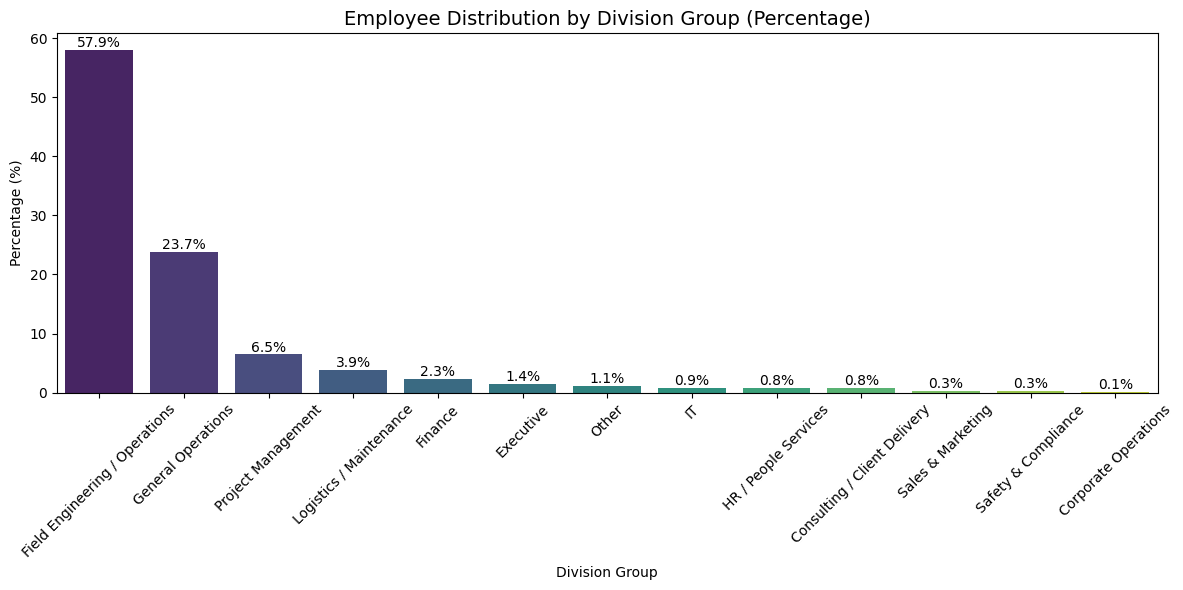


📘 Explanation:
The 'Division' column originally contained a mix of functional teams, technical units, and general labels.
To make this data suitable for analysis, we grouped them into high-level categories such as:
- 'IT', 'Finance', 'Sales & Marketing', 'Project Management', etc.

The vertical bar chart now shows the percentage distribution of employees across these groups,
which helps in clearer comparison, visualization, and workforce decision-making.



In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = r"../data/raw/employee_data.csv"
df = pd.read_csv(file_path)

# Drop NA values in Division (optional)
df['Division'] = df['Division'].fillna('Unknown')

# Step 2: Define a function to map raw divisions into clean categories
def map_division_group(division):
    division = division.lower().strip()
    if 'finance' in division:
        return 'Finance'
    elif 'technology' in division or 'it' in division:
        return 'IT'
    elif 'sales' in division or 'marketing' in division:
        return 'Sales & Marketing'
    elif 'executive' in division:
        return 'Executive'
    elif 'people' in division:
        return 'HR / People Services'
    elif 'project management' in division:
        return 'Project Management'
    elif division.startswith('general'):
        return 'General Operations'
    elif any(keyword in division for keyword in ['aerial', 'splicing', 'engineers', 'field', 'wireline', 'underground', 'catv', 'isp']):
        return 'Field Engineering / Operations'
    elif 'consultant' in division:
        return 'Consulting / Client Delivery'
    elif any(x in division for x in ['yard', 'fleet', 'shop']):
        return 'Logistics / Maintenance'
    elif 'safety' in division:
        return 'Safety & Compliance'
    elif 'corp' in division:
        return 'Corporate Operations'
    elif division == 'unknown':
        return 'Unknown'
    else:
        return 'Other'

# Step 3: Apply the mapping function
df['DivisionGroup'] = df['Division'].apply(map_division_group)

# Step 5: Vertical bar plot with percentages
division_counts = df['DivisionGroup'].value_counts(normalize=True).mul(100).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=division_counts.index, y=division_counts.values, palette='viridis')
for i, v in enumerate(division_counts.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10)
plt.title("Employee Distribution by Division Group (Percentage)", fontsize=14)
plt.ylabel("Percentage (%)")
plt.xlabel("Division Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 6: Explanation
print("""
📘 Explanation:
The 'Division' column originally contained a mix of functional teams, technical units, and general labels.
To make this data suitable for analysis, we grouped them into high-level categories such as:
- 'IT', 'Finance', 'Sales & Marketing', 'Project Management', etc.

The vertical bar chart now shows the percentage distribution of employees across these groups,
which helps in clearer comparison, visualization, and workforce decision-making.
""")


In [5]:
import pandas as pd

# Load dataset
file_path = r"../data/raw/employee_data.csv"
df = pd.read_csv(file_path)

# List of columns to analyze
columns_to_check = ['JobFunctionDescription']

# Print unique values as Python lists
for column in columns_to_check:
    unique_values = df[column].dropna().unique().tolist()
    print(f"\n🔹 Unique values in column '{column}':")
    print(unique_values)



🔹 Unique values in column 'JobFunctionDescription':
['Accounting', 'Labor', 'Assistant', 'Clerk', 'Laborer', 'Driver', 'Technician', 'Engineer', 'Executive Assistant', 'Splicer', 'Controller', 'Lineman', 'Coordinator', 'Director', 'Supervisor', 'Driller', 'Specialist', 'Operator', 'Foreman', 'Manager', 'Tower Hand', 'Mechanic', 'Flagger', 'Groundman', 'Model Assistant', 'Administrator', 'Project Manager', 'Electrician', 'Project Controls', 'Top Hand', 'Administrative', 'Locator', 'Billing', 'Cpo', 'Drafter', 'Vp', 'Construction Manager', 'Welder', 'Field Project Manager', 'Apprentice', 'Runner', 'Inspector', 'Field Technician', 'Associate', 'Administration', 'Intern', 'Planner', 'Accountant', 'General Manager', 'Clerical', 'Principal', 'Tester', 'Purchasing', 'Helper', 'Safety', 'Crew Leader', 'Program Manager', 'Shop', 'Project Coordinator', 'Estimator', 'Recruiting', 'Support', 'Ceo', 'Safety Manager', 'Warehouse Technician', 'Analyst', 'Generalist', 'Business Development', 'Cio', '


📘 Mapping Keywords Used for Each Job Function Group:
• Engineering: ['engineer', 'drafter', 'planner']
• Field Operations: ['technician', 'lineman', 'field', 'tower', 'operator', 'driller']
• Labor & Site Work: ['labor', 'laborer', 'helper', 'flagger', 'groundman', 'civil hand']
• Project / Site Management: ['manager', 'supervisor', 'foreman', 'coordinator', 'project']
• Executive & Leadership: ['vp', 'ceo', 'cfo', 'cio', 'evp', 'svp', 'chief', 'executive', 'director', 'principal']
• Finance & Analysis: ['analyst', 'accountant', 'accounting', 'controller', 'billing', 'purchasing', 'estimator']
• Admin & Support: ['admin', 'assistant', 'clerk', 'runner', 'support', 'administrator', 'clerical']
• Health & Safety: ['safety']
• Maintenance & Logistics: ['mechanic', 'shop', 'warehouse']
• HR / Talent: ['recruit', 'hr', 'generalist']
• Internship: ['intern']
• Unknown: ['unknown']


C:\Users\alanm\AppData\Local\Temp\ipykernel_23708\1459031290.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=jobfunc_counts.index, y=jobfunc_counts.values, palette='cubehelix')


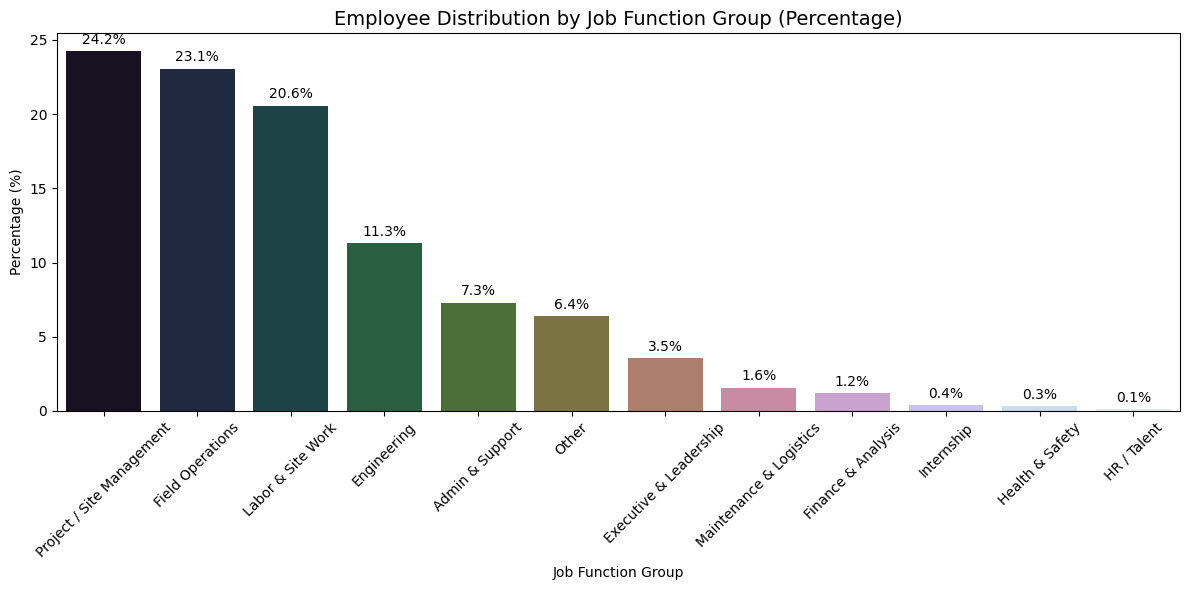


📘 Explanation:
The 'JobFunctionDescription' column originally had 70+ varied and inconsistent roles.

We grouped them into clear functional categories like:
- Engineering, Field Operations, Labor, Finance, Executive, Admin Support, etc.

🧩 Mapping Example:
- 'Admin & Support' includes roles with keywords: admin, clerk, support, assistant, etc.
- 'Finance & Analysis' includes analyst, accountant, estimator, etc.

This helps reduce complexity and improve:
- Workforce planning
- Role-based analysis
- Performance or attrition tracking by job type



In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = r"../data/raw/employee_data.csv"
df = pd.read_csv(file_path)

# Fill NA values (optional)
df['JobFunctionDescription'] = df['JobFunctionDescription'].fillna('Unknown')

# Step 2: Define mapping dictionary (for explanation printing)
mapping_keywords = {
    'Engineering': ['engineer', 'drafter', 'planner'],
    'Field Operations': ['technician', 'lineman', 'field', 'tower', 'operator', 'driller'],
    'Labor & Site Work': ['labor', 'laborer', 'helper', 'flagger', 'groundman', 'civil hand'],
    'Project / Site Management': ['manager', 'supervisor', 'foreman', 'coordinator', 'project'],
    'Executive & Leadership': ['vp', 'ceo', 'cfo', 'cio', 'evp', 'svp', 'chief', 'executive', 'director', 'principal'],
    'Finance & Analysis': ['analyst', 'accountant', 'accounting', 'controller', 'billing', 'purchasing', 'estimator'],
    'Admin & Support': ['admin', 'assistant', 'clerk', 'runner', 'support', 'administrator', 'clerical'],
    'Health & Safety': ['safety'],
    'Maintenance & Logistics': ['mechanic', 'shop', 'warehouse'],
    'HR / Talent': ['recruit', 'hr', 'generalist'],
    'Internship': ['intern'],
    'Unknown': ['unknown']
}

# Step 2.1: Print the keyword mappings for reference
print("\n📘 Mapping Keywords Used for Each Job Function Group:")
for group, keywords in mapping_keywords.items():
    print(f"• {group}: {keywords}")

# Step 3: Mapping function to group roles
def map_job_function_group(role):
    role = role.lower().strip()
    for group, keywords in mapping_keywords.items():
        if any(x in role for x in keywords):
            return group
    return 'Other'

# Step 4: Apply mapping
df['JobFunctionGroup'] = df['JobFunctionDescription'].apply(map_job_function_group)

# Step 6: Vertical bar chart with percentage
jobfunc_counts = df['JobFunctionGroup'].value_counts(normalize=True).mul(100).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=jobfunc_counts.index, y=jobfunc_counts.values, palette='cubehelix')
for i, v in enumerate(jobfunc_counts.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10)
plt.title("Employee Distribution by Job Function Group (Percentage)", fontsize=14)
plt.ylabel("Percentage (%)")
plt.xlabel("Job Function Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 7: Explanation
print("""
📘 Explanation:
The 'JobFunctionDescription' column originally had 70+ varied and inconsistent roles.

We grouped them into clear functional categories like:
- Engineering, Field Operations, Labor, Finance, Executive, Admin Support, etc.

🧩 Mapping Example:
- 'Admin & Support' includes roles with keywords: admin, clerk, support, assistant, etc.
- 'Finance & Analysis' includes analyst, accountant, estimator, etc.

This helps reduce complexity and improve:
- Workforce planning
- Role-based analysis
- Performance or attrition tracking by job type
""")


In [7]:
import pandas as pd

# Load dataset
file_path = r"../data/raw/employee_data.csv"
df = pd.read_csv(file_path)

# List of columns to analyze
columns_to_check = ['State']

# Print unique values as Python lists
for column in columns_to_check:
    unique_values = df[column].dropna().unique().tolist()
    print(f"\n🔹 Unique values in column '{column}':")
    print(unique_values)



🔹 Unique values in column 'State':
['MA', 'ND', 'FL', 'CT', 'CA', 'OR', 'TX', 'IN', 'GA', 'CO', 'KY', 'NV', 'VT', 'PA', 'RI', 'VA', 'UT', 'ID', 'MT', 'WA', 'AZ', 'NH', 'AL', 'OH', 'NY', 'ME', 'TN', 'NC']


📘 Region Mapping Keywords Used for Grouping States:
• West: ['CA', 'OR', 'WA', 'NV', 'AZ', 'UT', 'ID', 'MT']
• Midwest: ['ND', 'IN', 'OH']
• South: ['TX', 'FL', 'GA', 'AL', 'KY', 'TN', 'NC', 'VA']
• Northeast: ['MA', 'CT', 'RI', 'VT', 'NY', 'PA', 'NH', 'ME']
• Unknown: ['Unknown']


C:\Users\alanm\AppData\Local\Temp\ipykernel_23708\4264813511.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_counts.index, y=region_counts.values, palette='Set2')
C:\Users\alanm\AppData\Local\Temp\ipykernel_23708\4264813511.py:46: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\alanm\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


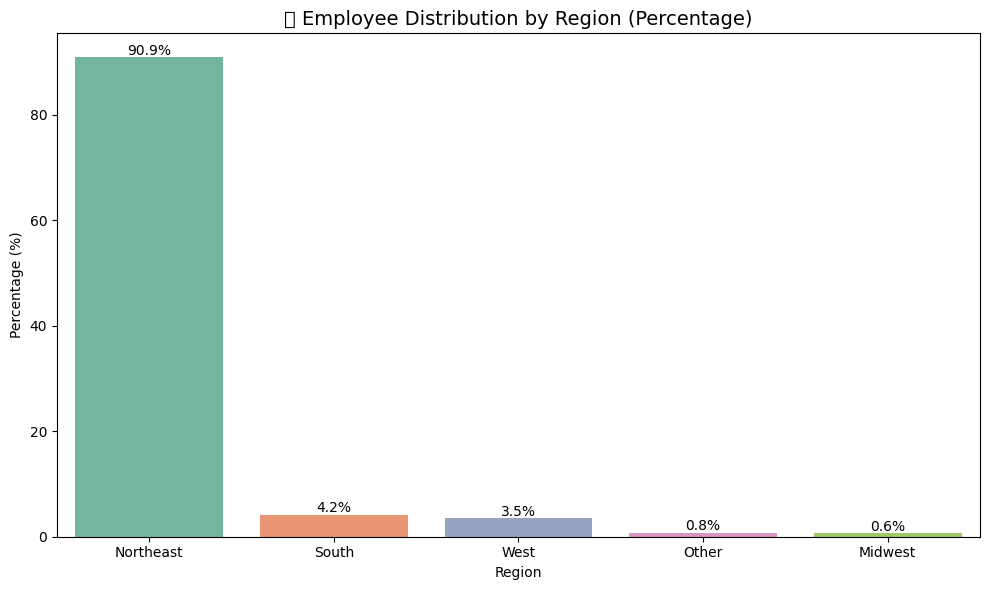


📘 Explanation:
The 'State' column was mapped into broader U.S. regions using a custom dictionary:
- West, Midwest, South, Northeast, and Other
- 'Unknown' was explicitly preserved

Why this helps:
✅ Easier analysis of regional trends
✅ Simplified geographic insights in dashboards
✅ Useful for planning HR strategy, resource allocation, and identifying workforce clusters



In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = r"../data/raw/employee_data.csv"
df = pd.read_csv(file_path)

# Step 1: Handle missing values
df['State'] = df['State'].fillna('Unknown')

# Step 2: Region mapping dictionary
region_mapping = {
    'West':     ['CA', 'OR', 'WA', 'NV', 'AZ', 'UT', 'ID', 'MT'],
    'Midwest':  ['ND', 'IN', 'OH'],
    'South':    ['TX', 'FL', 'GA', 'AL', 'KY', 'TN', 'NC', 'VA'],
    'Northeast':['MA', 'CT', 'RI', 'VT', 'NY', 'PA', 'NH', 'ME'],
    'Unknown':  ['Unknown']  # explicit for clarity
}

# Step 2.1: Print mapping explanation
print("📘 Region Mapping Keywords Used for Grouping States:")
for region, states in region_mapping.items():
    print(f"• {region}: {states}")

# Step 3: Function to map state to region
def map_region(state):
    for region, states in region_mapping.items():
        if state in states:
            return region
    return 'Other'

# Step 4: Apply region mapping
df['Region'] = df['State'].apply(map_region)

# Step 6: Plot region-wise employee distribution
region_counts = df['Region'].value_counts(normalize=True).mul(100).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=region_counts.index, y=region_counts.values, palette='Set2')
for i, v in enumerate(region_counts.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10)
plt.title("🌍 Employee Distribution by Region (Percentage)", fontsize=14)
plt.ylabel("Percentage (%)")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

# Step 7: Final Explanation
print("""
📘 Explanation:
The 'State' column was mapped into broader U.S. regions using a custom dictionary:
- West, Midwest, South, Northeast, and Other
- 'Unknown' was explicitly preserved

Why this helps:
✅ Easier analysis of regional trends
✅ Simplified geographic insights in dashboards
✅ Useful for planning HR strategy, resource allocation, and identifying workforce clusters
""")


🔹 BEFORE Date Conversion:
      StartDate   ExitDate         DOB
1801  12-Aug-18  13-Jun-22  16-09-1942
1190  18-Feb-22        NaN  27-12-1991
1817   4-Aug-22        NaN   8/12/1949
251   22-Jul-21        NaN  24-05-1999
2505  19-Aug-21  25-May-23  13-01-1948

🔸 AFTER Date Conversion & Derived Features:
      StartDate   ExitDate        DOB  IsActive        Age  TenureDays
1801 2018-08-12 2022-06-13        NaT     False        NaN        1401
1190 2022-02-18        NaT        NaT      True        NaN        1229
1817 2022-08-04        NaT 1949-12-08      True  75.561944        1062
251  2021-07-22        NaT        NaT      True        NaN        1440
2505 2021-08-19 2023-05-25        NaT     False        NaN         644

✅ Fully cleaned and simplified dataset saved to: D:\DATASCIENCE AND AI\ANALYTICS\internship\mark 5\cleaned dataset full\cleaned_mapped_employee_data.csv


C:\Users\alanm\AppData\Local\Temp\ipykernel_12328\3724256849.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['StartDate'] = pd.to_datetime(df['StartDate'], errors='coerce')
C:\Users\alanm\AppData\Local\Temp\ipykernel_12328\3724256849.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ExitDate'] = pd.to_datetime(df['ExitDate'], errors='coerce')
C:\Users\alanm\AppData\Local\Temp\ipykernel_12328\3724256849.py:199: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.values, y=value_counts.index, palette='viridis', ax=ax)
C:\Users\alanm\AppData\

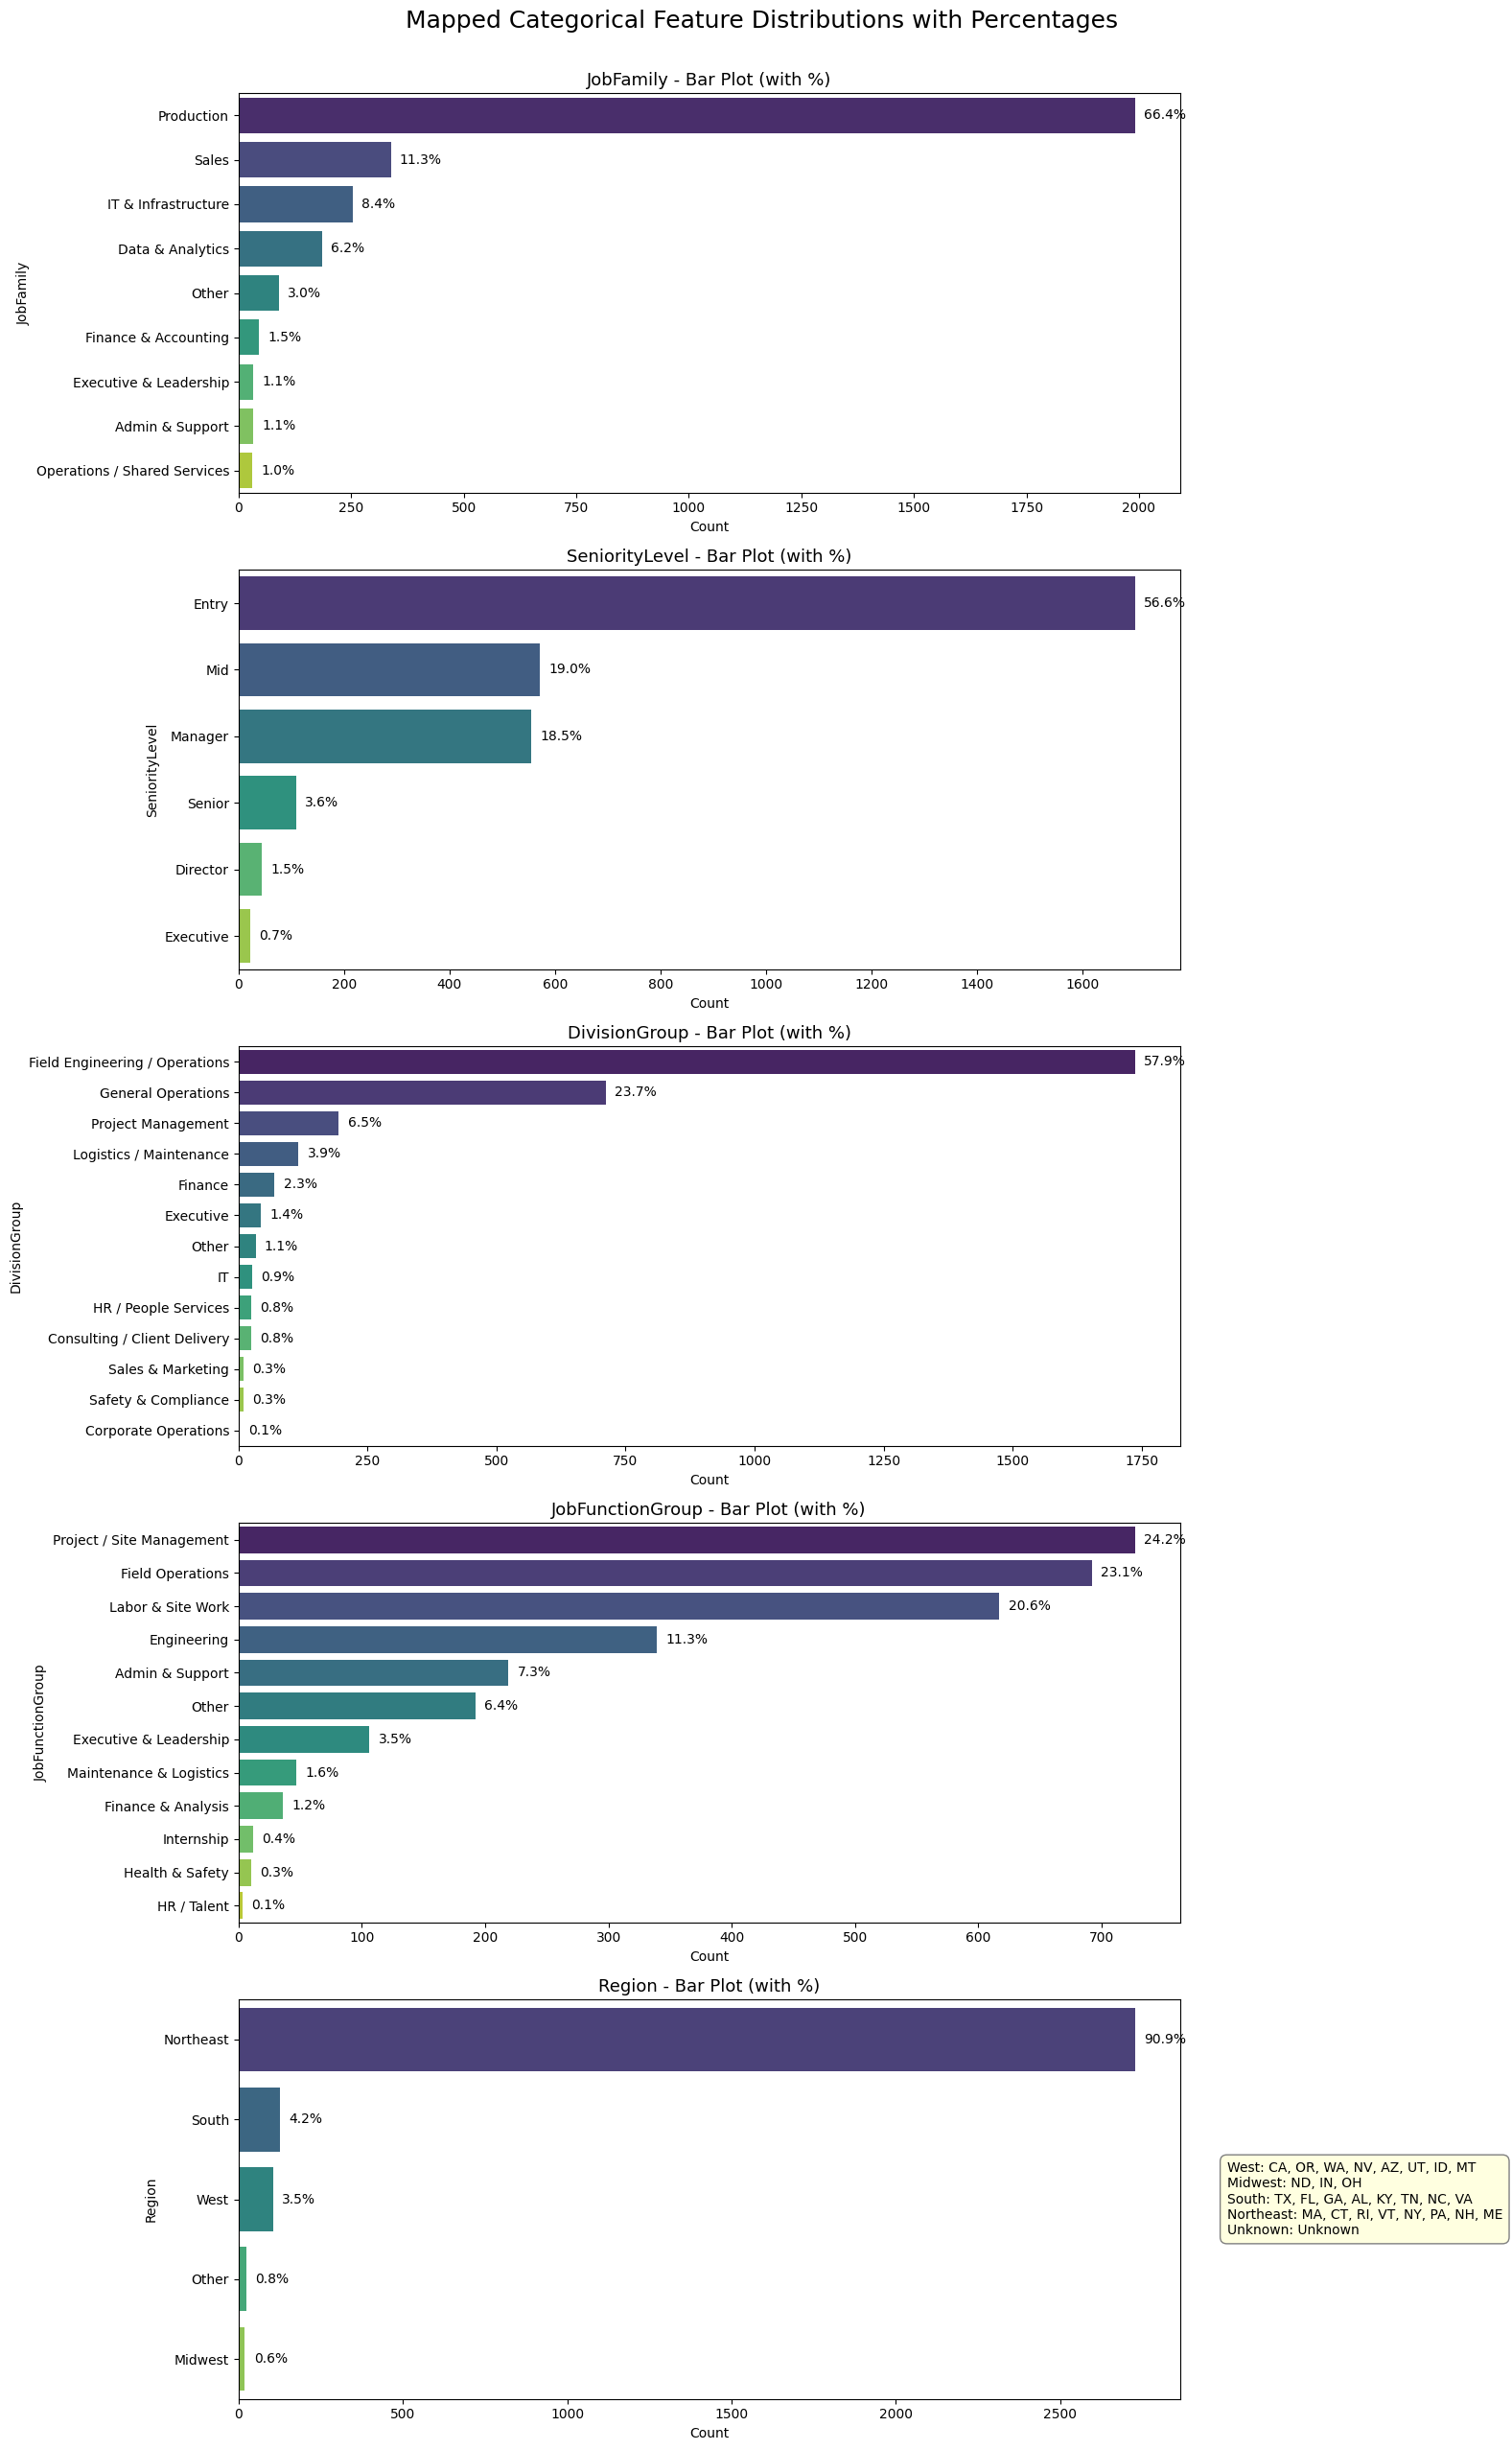

In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Define paths
input_path = r"../data/raw/employee_data.csv"
output_folder = "../data/processed/"
os.makedirs(output_folder, exist_ok=True)

# Step 2: Load dataset
df = pd.read_csv(input_path)

# Step 3: Drop irrelevant columns
df.drop(columns=['FirstName', 'LastName', 'ADEmail'], errors='ignore', inplace=True)

# Step 4: Convert StartDate, ExitDate, and DOB to datetime
sample_indices = df.sample(5, random_state=42).index
print("🔹 BEFORE Date Conversion:")
print(df.loc[sample_indices, ['StartDate', 'ExitDate', 'DOB']])

# Convert date fields to datetime
df['StartDate'] = pd.to_datetime(df['StartDate'], errors='coerce')
df['ExitDate'] = pd.to_datetime(df['ExitDate'], errors='coerce')

# Handle DOB with mixed formats
df['DOB'] = pd.to_datetime(df['DOB'], errors='coerce', dayfirst=True)

# Set IsActive
df['IsActive'] = df['ExitDate'].isna()

# Compute Age (in years)
# Compute Age (in years) safely
today = pd.Timestamp.today()
df['Age'] = ((today - df['DOB']).dt.days / 365.25)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')  # Keeps NaNs (float)


# Compute Tenure (in days)
df['TenureDays'] = (
    (df['ExitDate'].fillna(today) - df['StartDate']).dt.days
)

# Sample view after processing
print("\n🔸 AFTER Date Conversion & Derived Features:")
print(df.loc[sample_indices, ['StartDate', 'ExitDate', 'DOB', 'IsActive', 'Age', 'TenureDays']])


# Step 5: Clean and map Title → JobFamily
df['Title'] = df['Title'].str.strip()

def map_job_family(title):
    title = title.lower()
    if 'data' in title or 'bi' in title or 'dba' in title or 'analyst' in title:
        return 'Data & Analytics'
    elif 'it' in title or 'network' in title or 'infra' in title or 'support' in title:
        return 'IT & Infrastructure'
    elif 'sales' in title:
        return 'Sales'
    elif 'accountant' in title:
        return 'Finance & Accounting'
    elif 'president' in title or 'ceo' in title or 'cio' in title or 'director' in title:
        return 'Executive & Leadership'
    elif 'manager' in title and 'production' not in title:
        return 'Operations / Shared Services'
    elif 'production' in title:
        return 'Production'
    elif 'admin' in title:
        return 'Admin & Support'
    else:
        return 'Other'

def map_seniority_level(title):
    title = title.lower()
    if 'president' in title or 'ceo' in title or 'cio' in title:
        return 'Executive'
    elif 'director' in title:
        return 'Director'
    elif 'manager' in title:
        return 'Manager'
    elif 'sr' in title or 'senior' in title or 'principal' in title:
        return 'Senior'
    elif 'i' in title and 'ii' not in title:
        return 'Entry'
    elif 'ii' in title:
        return 'Mid'
    else:
        return 'Mid'

df['SeniorityLevel'] = df['Title'].apply(map_seniority_level)
df['Title'] = df['Title'].apply(map_job_family)  # Replace Title with mapped JobFamily

# Step 6: Clean and map Division → DivisionGroup
df['Division'] = df['Division'].fillna('Unknown')

def map_division_group(division):
    division = division.lower().strip()
    if 'finance' in division:
        return 'Finance'
    elif 'technology' in division or 'it' in division:
        return 'IT'
    elif 'sales' in division or 'marketing' in division:
        return 'Sales & Marketing'
    elif 'executive' in division:
        return 'Executive'
    elif 'people' in division:
        return 'HR / People Services'
    elif 'project management' in division:
        return 'Project Management'
    elif division.startswith('general'):
        return 'General Operations'
    elif any(keyword in division for keyword in ['aerial', 'splicing', 'engineers', 'field', 'wireline', 'underground', 'catv', 'isp']):
        return 'Field Engineering / Operations'
    elif 'consultant' in division:
        return 'Consulting / Client Delivery'
    elif any(x in division for x in ['yard', 'fleet', 'shop']):
        return 'Logistics / Maintenance'
    elif 'safety' in division:
        return 'Safety & Compliance'
    elif 'corp' in division:
        return 'Corporate Operations'
    elif division == 'unknown':
        return 'Unknown'
    else:
        return 'Other'

df['Division'] = df['Division'].apply(map_division_group)

# Step 7: Clean and map JobFunctionDescription → JobFunctionGroup
df['JobFunctionDescription'] = df['JobFunctionDescription'].fillna('Unknown')

mapping_keywords = {
    'Engineering': ['engineer', 'drafter', 'planner'],
    'Field Operations': ['technician', 'lineman', 'field', 'tower', 'operator', 'driller'],
    'Labor & Site Work': ['labor', 'laborer', 'helper', 'flagger', 'groundman', 'civil hand'],
    'Project / Site Management': ['manager', 'supervisor', 'foreman', 'coordinator', 'project'],
    'Executive & Leadership': ['vp', 'ceo', 'cfo', 'cio', 'evp', 'svp', 'chief', 'executive', 'director', 'principal'],
    'Finance & Analysis': ['analyst', 'accountant', 'accounting', 'controller', 'billing', 'purchasing', 'estimator'],
    'Admin & Support': ['admin', 'assistant', 'clerk', 'runner', 'support', 'administrator', 'clerical'],
    'Health & Safety': ['safety'],
    'Maintenance & Logistics': ['mechanic', 'shop', 'warehouse'],
    'HR / Talent': ['recruit', 'hr', 'generalist'],
    'Internship': ['intern'],
    'Unknown': ['unknown']
}

def map_job_function_group(role):
    role = role.lower().strip()
    for group, keywords in mapping_keywords.items():
        if any(x in role for x in keywords):
            return group
    return 'Other'

df['JobFunctionDescription'] = df['JobFunctionDescription'].apply(map_job_function_group)

# Step 8: Clean and map State → Region
df['State'] = df['State'].fillna('Unknown')

region_mapping = {
    'West':     ['CA', 'OR', 'WA', 'NV', 'AZ', 'UT', 'ID', 'MT'],
    'Midwest':  ['ND', 'IN', 'OH'],
    'South':    ['TX', 'FL', 'GA', 'AL', 'KY', 'TN', 'NC', 'VA'],
    'Northeast':['MA', 'CT', 'RI', 'VT', 'NY', 'PA', 'NH', 'ME'],
    'Unknown':  ['Unknown']
}

def map_region(state):
    for region, states in region_mapping.items():
        if state in states:
            return region
    return 'Other'

df['State'] = df['State'].apply(map_region)

# Step 9: Rename columns to reflect cleaned mappings
df.rename(columns={
    'Title': 'JobFamily',
    'Division': 'DivisionGroup',
    'JobFunctionDescription': 'JobFunctionGroup',
    'State': 'Region'
}, inplace=True)

# Step 10: Save cleaned dataset
output_path = os.path.join(output_folder, "cleaned_mapped_employee_data.csv")
df.to_csv(output_path, index=False)
print(f"\n✅ Fully cleaned and simplified dataset saved to: {output_path}")

# Step 11: Visualize mapped columns
columns_to_analyze = ['JobFamily', 'SeniorityLevel', 'DivisionGroup', 'JobFunctionGroup', 'Region']
num_cols = len(columns_to_analyze)
fig, axes = plt.subplots(num_cols, 1, figsize=(16, 5 * num_cols))

for idx, column_name in enumerate(columns_to_analyze):
    ax = axes[idx]
    value_counts = df[column_name].value_counts()
    total = value_counts.sum()
    percent = (value_counts / total * 100).round(1).astype(str) + '%'

    sns.barplot(x=value_counts.values, y=value_counts.index, palette='viridis', ax=ax)

    # Add annotations
    for i, (val, pct) in enumerate(zip(value_counts.values, percent)):
        ax.text(val + max(value_counts.values)*0.01, i, pct, va='center', fontsize=10)

    ax.set_title(f"{column_name} - Bar Plot (with %)", fontsize=13)
    ax.set_xlabel("Count")
    ax.set_ylabel(column_name)

    # Region description box
    if column_name == "Region":
        textstr = '\n'.join([
            f"West: {', '.join(region_mapping['West'])}",
            f"Midwest: {', '.join(region_mapping['Midwest'])}",
            f"South: {', '.join(region_mapping['South'])}",
            f"Northeast: {', '.join(region_mapping['Northeast'])}",
            f"Unknown: Unknown"
        ])
        props = dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor='gray')
        ax.text(1.05, 0.5, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='center', bbox=props)

plt.tight_layout()
plt.suptitle("Mapped Categorical Feature Distributions with Percentages", fontsize=18, y=1.02)
plt.show()
